# **Breast Cancer Risk Prediction using Machine Learning**



<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:120%; text-align:left">

<h3 align="left"><font color=red>Problem Statement:</font></h3>
The objective of this project is to analyze breast cancer patient data from the METABRIC dataset and predict the patient’s survival status based on clinical and biological features.
This analysis helps doctors and researchers understand which factors influence breast cancer outcomes and supports better treatment planning and decision-making.

<div style="border-radius:10px; padding: 15px; background-color: #facfc8; font-size:120%; text-align:left">

<h3 align="left"><font color=red>Dataset Description:</font></h3>

Dataset Description

This dataset is used for building a Breast Cancer Patient Survival Prediction model.
Each row in the dataset represents an individual breast cancer patient, and each column represents a specific clinical, pathological, or genetic attribute related to the patient.
The main objective of this dataset is to analyze these features and predict the survival status of the patient.

Dataset Structure

Rows: Each row corresponds to one breast cancer patient.

Columns: Each column represents a feature describing patient information such as age, tumor characteristics, treatment details, and genetic markers.

Target Variable:
Patient’s Vital Status – indicates whether the patient is Alive (1) or Dead of Disease (0).

Features

Patient ID

Age at Diagnosis

Overall Survival Status

Overall Survival (Months)

Relapse Free Status

Relapse Free Survival (Months)

ER Status

PR Status

HER2 Status

Tumor Size

Tumor Stage

Tumor Grade

Lymph Node Status

Treatment Type

Chemotherapy Status

Hormone Therapy Status

Radiation Therapy Status

# Step 1: Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
from matplotlib.colors import ListedColormap
import warnings
warnings.filterwarnings("ignore")
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import KFold

import joblib
import shap
from sklearn.inspection import PartialDependenceDisplay
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier

# Step 2: Data load

In [ ]:
df = pd.read_csv('/content/Breast Cancer METABRIC.csv')

# Step 3: EDA (Exploratory Data Analysis)
EDA is the process of understanding your data by looking at it, cleaning it, and finding patterns, trends, and problems before building any model.

In [ ]:
df

,Patient ID,Age at Diagnosis,Type of Breast Surgery,Cancer Type,Cancer Type Detailed,Cellularity,Chemotherapy,Pam50 + Claudin-low subtype,Cohort,ER status measured by IHC,...,Overall Survival Status,PR Status,Radio Therapy,Relapse Free Status (Months),Relapse Free Status,Sex,3-Gene classifier subtype,Tumor Size,Tumor Stage,Patient's Vital Status
0,MB-0000,75.65,Mastectomy,Breast Cancer,Breast Invasive Ductal Carcinoma,NaN,No,claudin-low,1.0,Positve,...,Living,Negative,Yes,138.65,Not Recurred,Female,ER-/HER2-,22.0,2.0,Living
1,MB-0002,43.19,Breast Conserving,Breast Cancer,Breast Invasive Ductal Carcinoma,High,No,LumA,1.0,Positve,...,Living,Positive,Yes,83.52,Not Recurred,Female,ER+/HER2- High Prolif,10.0,1.0,Living
2,MB-0005,48.87,Mastectomy,Breast Cancer,Breast Invasive Ductal Carcinoma,High,Yes,LumB,1.0,Positve,...,Deceased,Positive,No,151.28,Recurred,Female,NaN,15.0,2.0,Died of Disease
3,MB-0006,47.68,Mastectomy,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,Moderate,Yes,LumB,1.0,Positve,...,Living,Positive,Yes,162.76,Not Recurred,Female,NaN,25.0,2.0,Living
4,MB-0008,76.97,Mastectomy,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,High,Yes,LumB,1.0,Positve,...,Deceased,Positive,Yes,18.55,Recurred,Female,ER+/HER2- High Prolif,40.0,2.0,Died of Disease
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2504,MTS-T2428,70.05,NaN,Breast Cancer,Invasive Breast Carcinoma,NaN,NaN,NaN,1.0,Positve,...,NaN,NaN,NaN,4.93,Recurred,Female,NaN,27.0,1.0,NaN
2505,MTS-T2429,63.60,NaN,Breast Cancer,Invasive Breast Carcinoma,NaN,NaN,NaN,1.0,Positve,...,NaN,NaN,NaN,16.18,Recurred,Female,NaN,28.0,2.0,NaN
2506,MTS-T2430,NaN,NaN,Breast Cancer,Invasive Breast Carcinoma,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Female,NaN,NaN,0.0,NaN
2507,MTS-T2431,NaN,NaN,Breast Cancer,Invasive Breast Carcinoma,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Female,NaN,NaN,0.0,NaN


In [ ]:
df.head()

,Patient ID,Age at Diagnosis,Type of Breast Surgery,Cancer Type,Cancer Type Detailed,Cellularity,Chemotherapy,Pam50 + Claudin-low subtype,Cohort,ER status measured by IHC,...,Overall Survival Status,PR Status,Radio Therapy,Relapse Free Status (Months),Relapse Free Status,Sex,3-Gene classifier subtype,Tumor Size,Tumor Stage,Patient's Vital Status
0,MB-0000,75.65,Mastectomy,Breast Cancer,Breast Invasive Ductal Carcinoma,NaN,No,claudin-low,1.0,Positve,...,Living,Negative,Yes,138.65,Not Recurred,Female,ER-/HER2-,22.0,2.0,Living
1,MB-0002,43.19,Breast Conserving,Breast Cancer,Breast Invasive Ductal Carcinoma,High,No,LumA,1.0,Positve,...,Living,Positive,Yes,83.52,Not Recurred,Female,ER+/HER2- High Prolif,10.0,1.0,Living
2,MB-0005,48.87,Mastectomy,Breast Cancer,Breast Invasive Ductal Carcinoma,High,Yes,LumB,1.0,Positve,...,Deceased,Positive,No,151.28,Recurred,Female,NaN,15.0,2.0,Died of Disease
3,MB-0006,47.68,Mastectomy,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,Moderate,Yes,LumB,1.0,Positve,...,Living,Positive,Yes,162.76,Not Recurred,Female,NaN,25.0,2.0,Living
4,MB-0008,76.97,Mastectomy,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,High,Yes,LumB,1.0,Positve,...,Deceased,Positive,Yes,18.55,Recurred,Female,ER+/HER2- High Prolif,40.0,2.0,Died of Disease


In [ ]:
df.tail()

,Patient ID,Age at Diagnosis,Type of Breast Surgery,Cancer Type,Cancer Type Detailed,Cellularity,Chemotherapy,Pam50 + Claudin-low subtype,Cohort,ER status measured by IHC,...,Overall Survival Status,PR Status,Radio Therapy,Relapse Free Status (Months),Relapse Free Status,Sex,3-Gene classifier subtype,Tumor Size,Tumor Stage,Patient's Vital Status
2504,MTS-T2428,70.05,NaN,Breast Cancer,Invasive Breast Carcinoma,NaN,NaN,NaN,1.0,Positve,...,NaN,NaN,NaN,4.93,Recurred,Female,NaN,27.0,1.0,NaN
2505,MTS-T2429,63.60,NaN,Breast Cancer,Invasive Breast Carcinoma,NaN,NaN,NaN,1.0,Positve,...,NaN,NaN,NaN,16.18,Recurred,Female,NaN,28.0,2.0,NaN
2506,MTS-T2430,NaN,NaN,Breast Cancer,Invasive Breast Carcinoma,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Female,NaN,NaN,0.0,NaN
2507,MTS-T2431,NaN,NaN,Breast Cancer,Invasive Breast Carcinoma,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Female,NaN,NaN,0.0,NaN
2508,MTS-T2432,NaN,NaN,Breast Cancer,Invasive Breast Carcinoma,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Female,NaN,NaN,0.0,NaN


In [ ]:
df.shape

(2509, 34)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2509 entries, 0 to 2508
Data columns (total 34 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Patient ID                      2509 non-null   object 
 1   Age at Diagnosis                2498 non-null   float64
 2   Type of Breast Surgery          1955 non-null   object 
 3   Cancer Type                     2509 non-null   object 
 4   Cancer Type Detailed            2509 non-null   object 
 5   Cellularity                     1917 non-null   object 
 6   Chemotherapy                    1980 non-null   object 
 7   Pam50 + Claudin-low subtype     1980 non-null   object 
 8   Cohort                          2498 non-null   float64
 9   ER status measured by IHC       2426 non-null   object 
 10  ER Status                       2469 non-null   object 
 11  Neoplasm Histologic Grade       2388 non-null   float64
 12  HER2 status measured by SNP6    19

In [ ]:
df.describe()

,Age at Diagnosis,Cohort,Neoplasm Histologic Grade,Lymph nodes examined positive,Mutation Count,Nottingham prognostic index,Overall Survival (Months),Relapse Free Status (Months),Tumor Size,Tumor Stage
count,2498.000000,2498.000000,2388.000000,2243.000000,2357.000000,2287.000000,1981.000000,2388.000000,2360.000000,1788.000000
mean,60.420300,2.900320,2.412060,1.950513,5.578702,4.028787,125.244271,108.842487,26.220093,1.713647
std,13.032997,1.962216,0.649363,4.017774,3.967967,1.189092,76.111772,76.519494,15.370883,0.655307
min,21.930000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,50.920000,1.000000,2.000000,0.000000,3.000000,3.048000,60.866667,40.560000,17.000000,1.000000
50%,61.110000,3.000000,3.000000,0.000000,5.000000,4.044000,116.466667,99.095000,22.410000,2.000000
75%,70.000000,4.000000,3.000000,2.000000,7.000000,5.040000,185.133333,167.640000,30.000000,2.000000
max,96.290000,9.000000,3.000000,45.000000,80.000000,7.200000,355.200000,384.210000,182.000000,4.000000


In [ ]:
df.dtypes

,0
Patient ID,object
Age at Diagnosis,float64
Type of Breast Surgery,object
Cancer Type,object
Cancer Type Detailed,object
Cellularity,object
Chemotherapy,object
Pam50 + Claudin-low subtype,object
Cohort,float64
ER status measured by IHC,object


In [ ]:
df.columns.values

array(['Patient ID', 'Age at Diagnosis', 'Type of Breast Surgery',
       'Cancer Type', 'Cancer Type Detailed', 'Cellularity',
       'Chemotherapy', 'Pam50 + Claudin-low subtype', 'Cohort',
       'ER status measured by IHC', 'ER Status',
       'Neoplasm Histologic Grade', 'HER2 status measured by SNP6',
       'HER2 Status', 'Tumor Other Histologic Subtype', 'Hormone Therapy',
       'Inferred Menopausal State', 'Integrative Cluster',
       'Primary Tumor Laterality', 'Lymph nodes examined positive',
       'Mutation Count', 'Nottingham prognostic index', 'Oncotree Code',
       'Overall Survival (Months)', 'Overall Survival Status',
       'PR Status', 'Radio Therapy', 'Relapse Free Status (Months)',
       'Relapse Free Status', 'Sex', '3-Gene classifier subtype',
       'Tumor Size', 'Tumor Stage', "Patient's Vital Status"],
      dtype=object)

# Step 4: Handling Missing Value

In [ ]:
df

,Patient ID,Age at Diagnosis,Type of Breast Surgery,Cancer Type,Cancer Type Detailed,Cellularity,Chemotherapy,Pam50 + Claudin-low subtype,Cohort,ER status measured by IHC,...,Overall Survival Status,PR Status,Radio Therapy,Relapse Free Status (Months),Relapse Free Status,Sex,3-Gene classifier subtype,Tumor Size,Tumor Stage,Patient's Vital Status
0,MB-0000,75.65,Mastectomy,Breast Cancer,Breast Invasive Ductal Carcinoma,NaN,No,claudin-low,1.0,Positve,...,Living,Negative,Yes,138.65,Not Recurred,Female,ER-/HER2-,22.0,2.0,Living
1,MB-0002,43.19,Breast Conserving,Breast Cancer,Breast Invasive Ductal Carcinoma,High,No,LumA,1.0,Positve,...,Living,Positive,Yes,83.52,Not Recurred,Female,ER+/HER2- High Prolif,10.0,1.0,Living
2,MB-0005,48.87,Mastectomy,Breast Cancer,Breast Invasive Ductal Carcinoma,High,Yes,LumB,1.0,Positve,...,Deceased,Positive,No,151.28,Recurred,Female,NaN,15.0,2.0,Died of Disease
3,MB-0006,47.68,Mastectomy,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,Moderate,Yes,LumB,1.0,Positve,...,Living,Positive,Yes,162.76,Not Recurred,Female,NaN,25.0,2.0,Living
4,MB-0008,76.97,Mastectomy,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,High,Yes,LumB,1.0,Positve,...,Deceased,Positive,Yes,18.55,Recurred,Female,ER+/HER2- High Prolif,40.0,2.0,Died of Disease
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2504,MTS-T2428,70.05,NaN,Breast Cancer,Invasive Breast Carcinoma,NaN,NaN,NaN,1.0,Positve,...,NaN,NaN,NaN,4.93,Recurred,Female,NaN,27.0,1.0,NaN
2505,MTS-T2429,63.60,NaN,Breast Cancer,Invasive Breast Carcinoma,NaN,NaN,NaN,1.0,Positve,...,NaN,NaN,NaN,16.18,Recurred,Female,NaN,28.0,2.0,NaN
2506,MTS-T2430,NaN,NaN,Breast Cancer,Invasive Breast Carcinoma,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Female,NaN,NaN,0.0,NaN
2507,MTS-T2431,NaN,NaN,Breast Cancer,Invasive Breast Carcinoma,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Female,NaN,NaN,0.0,NaN


In [ ]:
df.isnull()

,Patient ID,Age at Diagnosis,Type of Breast Surgery,Cancer Type,Cancer Type Detailed,Cellularity,Chemotherapy,Pam50 + Claudin-low subtype,Cohort,ER status measured by IHC,...,Overall Survival Status,PR Status,Radio Therapy,Relapse Free Status (Months),Relapse Free Status,Sex,3-Gene classifier subtype,Tumor Size,Tumor Stage,Patient's Vital Status
0,False,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2504,False,False,True,False,False,True,True,True,False,False,...,True,True,True,False,False,False,True,False,False,True
2505,False,False,True,False,False,True,True,True,False,False,...,True,True,True,False,False,False,True,False,False,True
2506,False,True,True,False,False,True,True,True,True,True,...,True,True,True,True,True,False,True,True,False,True
2507,False,True,True,False,False,True,True,True,True,True,...,True,True,True,True,True,False,True,True,False,True


In [ ]:
df.isnull().sum()

,0
Patient ID,0
Age at Diagnosis,11
Type of Breast Surgery,554
Cancer Type,0
Cancer Type Detailed,0
Cellularity,592
Chemotherapy,529
Pam50 + Claudin-low subtype,529
Cohort,11
ER status measured by IHC,83


In [ ]:
df.isnull().mean()*100

,0
Patient ID,0.000000
Age at Diagnosis,0.438422
Type of Breast Surgery,22.080510
Cancer Type,0.000000
Cancer Type Detailed,0.000000
Cellularity,23.595058
Chemotherapy,21.084097
Pam50 + Claudin-low subtype,21.084097
Cohort,0.438422
ER status measured by IHC,3.308091


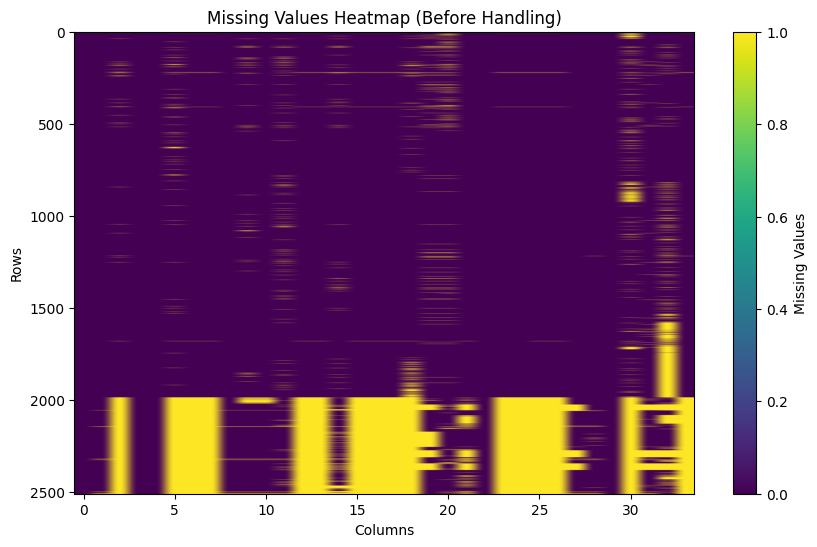

In [ ]:
plt.figure(figsize=(10, 6))
missing_matrix = df.isnull()
plt.imshow(missing_matrix, aspect='auto')
plt.title("Missing Values Heatmap (Before Handling)")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.colorbar(label="Missing Values")
plt.show()

In [ ]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns


In [ ]:
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

    # Fill missing numerical values with median


In [ ]:
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

    # Fill missing categorical values with 'mode'


In [ ]:
df.isnull().sum()

,0
Patient ID,0
Age at Diagnosis,0
Type of Breast Surgery,0
Cancer Type,0
Cancer Type Detailed,0
Cellularity,0
Chemotherapy,0
Pam50 + Claudin-low subtype,0
Cohort,0
ER status measured by IHC,0


In [ ]:
df

,Patient ID,Age at Diagnosis,Type of Breast Surgery,Cancer Type,Cancer Type Detailed,Cellularity,Chemotherapy,Pam50 + Claudin-low subtype,Cohort,ER status measured by IHC,...,Overall Survival Status,PR Status,Radio Therapy,Relapse Free Status (Months),Relapse Free Status,Sex,3-Gene classifier subtype,Tumor Size,Tumor Stage,Patient's Vital Status
0,MB-0000,75.65,Mastectomy,Breast Cancer,Breast Invasive Ductal Carcinoma,High,No,claudin-low,1.0,Positve,...,Living,Negative,Yes,138.650,Not Recurred,Female,ER-/HER2-,22.00,2.0,Living
1,MB-0002,43.19,Breast Conserving,Breast Cancer,Breast Invasive Ductal Carcinoma,High,No,LumA,1.0,Positve,...,Living,Positive,Yes,83.520,Not Recurred,Female,ER+/HER2- High Prolif,10.00,1.0,Living
2,MB-0005,48.87,Mastectomy,Breast Cancer,Breast Invasive Ductal Carcinoma,High,Yes,LumB,1.0,Positve,...,Deceased,Positive,No,151.280,Recurred,Female,ER+/HER2- Low Prolif,15.00,2.0,Died of Disease
3,MB-0006,47.68,Mastectomy,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,Moderate,Yes,LumB,1.0,Positve,...,Living,Positive,Yes,162.760,Not Recurred,Female,ER+/HER2- Low Prolif,25.00,2.0,Living
4,MB-0008,76.97,Mastectomy,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,High,Yes,LumB,1.0,Positve,...,Deceased,Positive,Yes,18.550,Recurred,Female,ER+/HER2- High Prolif,40.00,2.0,Died of Disease
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2504,MTS-T2428,70.05,Mastectomy,Breast Cancer,Invasive Breast Carcinoma,High,No,LumA,1.0,Positve,...,Deceased,Positive,Yes,4.930,Recurred,Female,ER+/HER2- Low Prolif,27.00,1.0,Living
2505,MTS-T2429,63.60,Mastectomy,Breast Cancer,Invasive Breast Carcinoma,High,No,LumA,1.0,Positve,...,Deceased,Positive,Yes,16.180,Recurred,Female,ER+/HER2- Low Prolif,28.00,2.0,Living
2506,MTS-T2430,61.11,Mastectomy,Breast Cancer,Invasive Breast Carcinoma,High,No,LumA,3.0,Positve,...,Deceased,Positive,Yes,99.095,Not Recurred,Female,ER+/HER2- Low Prolif,22.41,0.0,Living
2507,MTS-T2431,61.11,Mastectomy,Breast Cancer,Invasive Breast Carcinoma,High,No,LumA,3.0,Positve,...,Deceased,Positive,Yes,99.095,Not Recurred,Female,ER+/HER2- Low Prolif,22.41,0.0,Living


# step 5 : Univariate Analysis

1#Target Column
🎯 Patient's Vital Status (Alive vs Died)

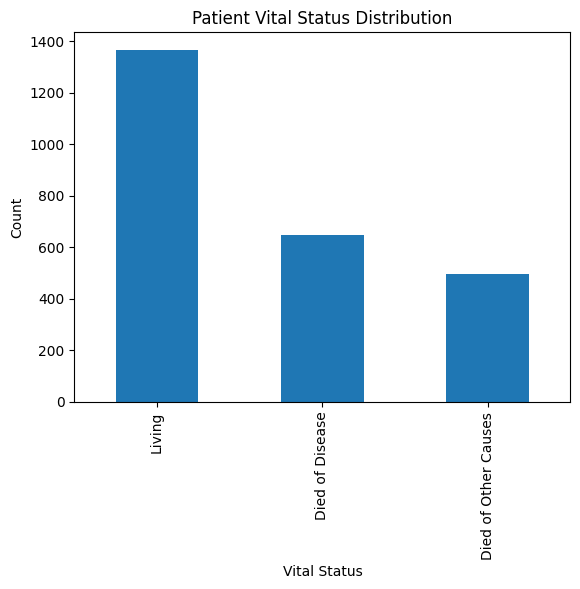

In [ ]:
plt.figure()
df["Patient's Vital Status"].value_counts().plot(kind='bar')
plt.title("Patient Vital Status Distribution")
plt.xlabel("Vital Status")
plt.ylabel("Count")
plt.show()


**Interpretation:**

“This bar chart shows the distribution of patients based on their vital status.
Most patients are living, as this category has the highest count.
The number of patients who died of disease is lower than living patients.
The lowest count is for patients who died due to other causes.”

Age at Diagnosis (Numerical)

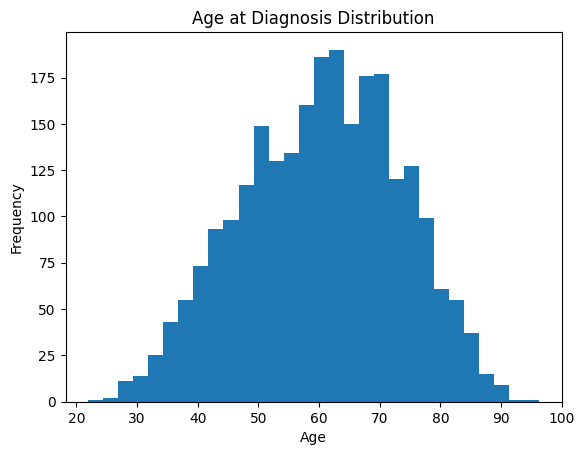

In [ ]:
plt.figure()
df["Age at Diagnosis"].plot(kind='hist', bins=30)
plt.title("Age at Diagnosis Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

**Interpretation:**

The histogram indicates that most breast cancer diagnoses occur in middle-aged and older patients. The age distribution is not uniform, suggesting that age may play an important role in patient survival outcomes.


Why this graph is important (Sir ke liye):

Understanding age distribution helps identify age-related risk patterns in breast cancer patients.

Tumor Stage (Categorical)

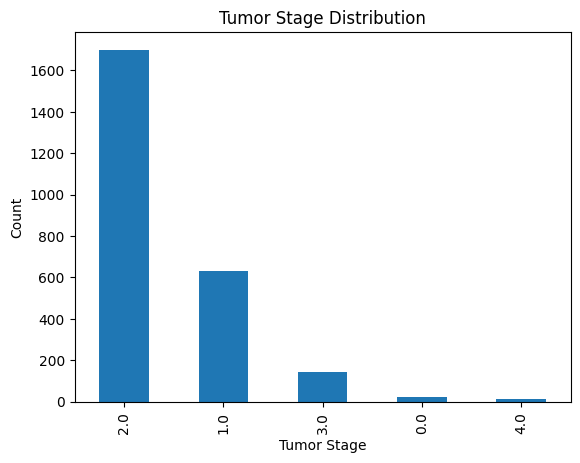

In [ ]:
plt.figure()
df["Tumor Stage"].value_counts().plot(kind='bar')
plt.title("Tumor Stage Distribution")
plt.xlabel("Tumor Stage")
plt.ylabel("Count")
plt.show()

**Interpretation:**

The bar chart indicates that certain tumor stages occur more frequently than others. This suggests that many patients are diagnosed at specific stages of cancer, which can directly impact treatment decisions and survival outcomes.

Why this graph is important (Sir ke liye):

Tumor stage is a key clinical factor that influences prognosis and treatment strategy.

# Cellularity



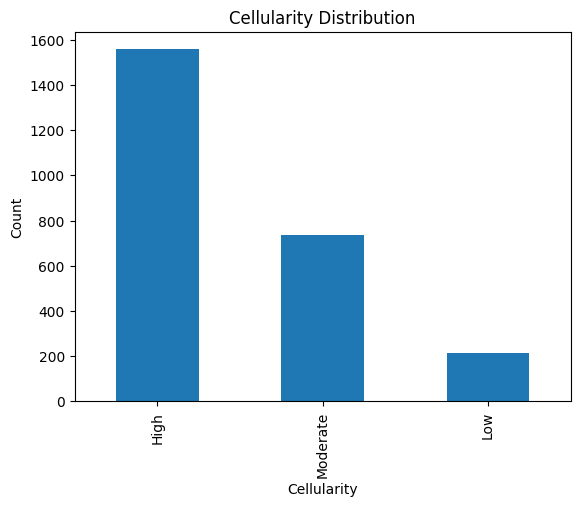

In [ ]:
plt.figure()
df["Cellularity"].value_counts().plot(kind='bar')
plt.title("Cellularity Distribution")
plt.xlabel("Cellularity")
plt.ylabel("Count")
plt.show()


**Interpretation:**

The bar chart shows that different levels of cellularity are present in the dataset, with some cellularity categories occurring more frequently than others. This indicates variability in tumor cell density, which can influence cancer aggressiveness and patient prognosis.

# # Chemotherapy

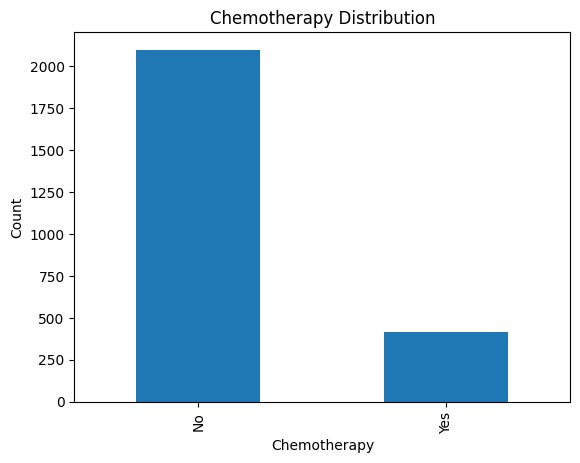

In [ ]:
plt.figure()
df["Chemotherapy"].value_counts().plot(kind='bar')
plt.title("Chemotherapy Distribution")
plt.xlabel("Chemotherapy")
plt.ylabel("Count")
plt.show()


**Interpretation:**

The bar chart indicates that chemotherapy was administered to a significant portion of patients, while mostly patients did not receive chemotherapy. This variation suggests that treatment decisions depend on tumor stage, patient condition, and clinical factors.

 # Step 6: Bivariate Analysis(Relationship) Age at Diagnosis 🆚 Patient’s Vital Status “Bade tumor size ke cases me risk zyada dikh raha hai.”


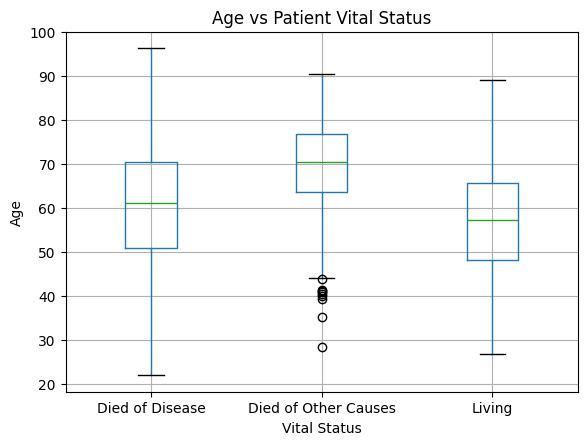

In [ ]:
df.boxplot(column="Age at Diagnosis",
           by="Patient's Vital Status")
plt.title("Age vs Patient Vital Status")
plt.suptitle("")
plt.xlabel("Vital Status")
plt.ylabel("Age")
plt.show()


**Interpretation:**

The box plot shows that patients who are alive generally tend to be diagnosed at a younger age compared to patients who are dead of disease. This indicates that age at diagnosis may have an impact on patient survival.

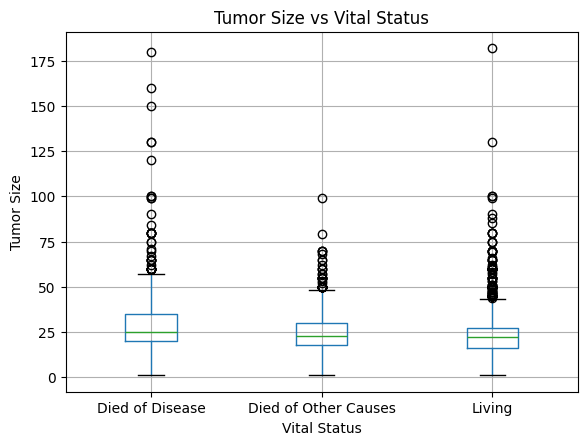

In [ ]:
df.boxplot(column="Tumor Size",
           by="Patient's Vital Status")
plt.title("Tumor Size vs Vital Status")
plt.suptitle("")
plt.xlabel("Vital Status")
plt.ylabel("Tumor Size")
plt.show()


# Age at Diagnosis vs Survival Bivariate Analysis (Relationship Graph)

<Axes: xlabel='Age at Diagnosis', ylabel='Count'>

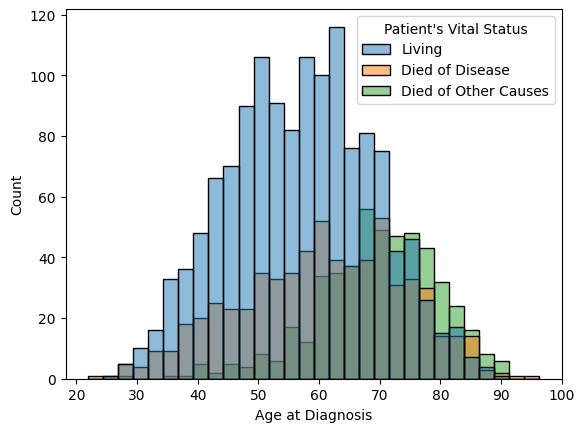

In [ ]:
sns.histplot(
    data=df,
    x='Age at Diagnosis',
    hue="Patient's Vital Status",
    bins=30
)

**Interpretation:**

“This graph shows the age at which patients were diagnosed and their final status.
Most patients were diagnosed between 40 to 70 years of age.
Patients who are living are mostly from the middle age group.
Patients who died (either due to disease or other causes) are more common in the higher age groups.
This suggests that age may affect patient survival.”

# Hormone Therapy 📊 Bar Chart

<Axes: xlabel='Hormone Therapy'>

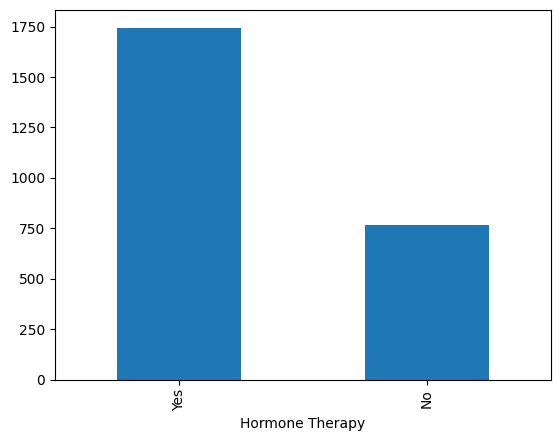

In [ ]:
df['Hormone Therapy'].value_counts().plot(kind='bar')

# Tumor Stage 🆚 Patient’s Vital Status
(Categorical vs Target) 📊 Graph: Grouped Bar Chart

“Higher tumor stage me death cases zyada hain.”


 # 4️⃣ Chemotherapy 🆚 Patient’s Vital Status

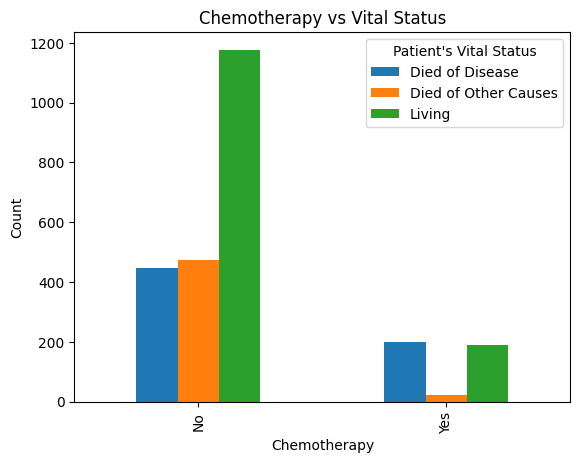

In [ ]:
pd.crosstab(df["Chemotherapy"],
            df["Patient's Vital Status"]).plot(kind='bar')
plt.title("Chemotherapy vs Vital Status")
plt.xlabel("Chemotherapy")
plt.ylabel("Count")
plt.show()



#PIE CHART
Patient’s Vital Status (Target Variable)

Is pie chart se dataset me alive aur died patients ka proportion dikh raha hai.




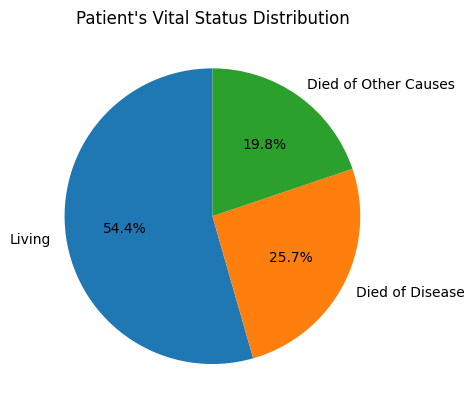

In [ ]:
df["Patient's Vital Status"].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Patient's Vital Status Distribution")
plt.ylabel("")
plt.show()


**Interpretation:**

“This pie chart shows the distribution of patients based on their vital status.
Most patients are living, which is about 54% of the total.
Around 26% of patients died due to the disease.
About 20% of patients died due to other causes.”

# Step 7 : Encoding

In [ ]:
df["Patient's Vital Status"].value_counts()


,count
Patient's Vital Status,
Living,1366
Died of Disease,646
Died of Other Causes,497


In [ ]:
df["Patient's Vital Status"].replace(to_replace='Living', value=1, inplace=True)
df["Patient's Vital Status"].replace(to_replace=['Died of Disease', 'Died of Other Causes'], value=0, inplace=True)

In [ ]:
df

,Patient ID,Age at Diagnosis,Type of Breast Surgery,Cancer Type,Cancer Type Detailed,Cellularity,Chemotherapy,Pam50 + Claudin-low subtype,Cohort,ER status measured by IHC,...,Overall Survival Status,PR Status,Radio Therapy,Relapse Free Status (Months),Relapse Free Status,Sex,3-Gene classifier subtype,Tumor Size,Tumor Stage,Patient's Vital Status
0,MB-0000,75.65,Mastectomy,Breast Cancer,Breast Invasive Ductal Carcinoma,High,No,claudin-low,1.0,Positve,...,Living,Negative,Yes,138.650,Not Recurred,Female,ER-/HER2-,22.00,2.0,1
1,MB-0002,43.19,Breast Conserving,Breast Cancer,Breast Invasive Ductal Carcinoma,High,No,LumA,1.0,Positve,...,Living,Positive,Yes,83.520,Not Recurred,Female,ER+/HER2- High Prolif,10.00,1.0,1
2,MB-0005,48.87,Mastectomy,Breast Cancer,Breast Invasive Ductal Carcinoma,High,Yes,LumB,1.0,Positve,...,Deceased,Positive,No,151.280,Recurred,Female,ER+/HER2- Low Prolif,15.00,2.0,0
3,MB-0006,47.68,Mastectomy,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,Moderate,Yes,LumB,1.0,Positve,...,Living,Positive,Yes,162.760,Not Recurred,Female,ER+/HER2- Low Prolif,25.00,2.0,1
4,MB-0008,76.97,Mastectomy,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,High,Yes,LumB,1.0,Positve,...,Deceased,Positive,Yes,18.550,Recurred,Female,ER+/HER2- High Prolif,40.00,2.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2504,MTS-T2428,70.05,Mastectomy,Breast Cancer,Invasive Breast Carcinoma,High,No,LumA,1.0,Positve,...,Deceased,Positive,Yes,4.930,Recurred,Female,ER+/HER2- Low Prolif,27.00,1.0,1
2505,MTS-T2429,63.60,Mastectomy,Breast Cancer,Invasive Breast Carcinoma,High,No,LumA,1.0,Positve,...,Deceased,Positive,Yes,16.180,Recurred,Female,ER+/HER2- Low Prolif,28.00,2.0,1
2506,MTS-T2430,61.11,Mastectomy,Breast Cancer,Invasive Breast Carcinoma,High,No,LumA,3.0,Positve,...,Deceased,Positive,Yes,99.095,Not Recurred,Female,ER+/HER2- Low Prolif,22.41,0.0,1
2507,MTS-T2431,61.11,Mastectomy,Breast Cancer,Invasive Breast Carcinoma,High,No,LumA,3.0,Positve,...,Deceased,Positive,Yes,99.095,Not Recurred,Female,ER+/HER2- Low Prolif,22.41,0.0,1


In [ ]:
  df["Patient's Vital Status"].value_counts()

,count
Patient's Vital Status,
1,1366
0,1143


In [ ]:
df["Patient's Vital Status"].unique()

array([1, 0])

In [ ]:
df = df.dropna(subset=["Patient's Vital Status"])

In [ ]:
# Target column
y = df["Patient's Vital Status"]

# Features: target column
X = df.drop(columns=["Patient's Vital Status"])

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])


In [ ]:
df

,Patient ID,Age at Diagnosis,Type of Breast Surgery,Cancer Type,Cancer Type Detailed,Cellularity,Chemotherapy,Pam50 + Claudin-low subtype,Cohort,ER status measured by IHC,...,Overall Survival Status,PR Status,Radio Therapy,Relapse Free Status (Months),Relapse Free Status,Sex,3-Gene classifier subtype,Tumor Size,Tumor Stage,Patient's Vital Status
0,0,75.65,1,0,2,0,0,6,1.0,1,...,1,0,1,138.650,0,0,2,22.00,2.0,1
1,1,43.19,0,0,2,0,0,2,1.0,1,...,1,1,1,83.520,0,0,0,10.00,1.0,1
2,2,48.87,1,0,2,0,1,3,1.0,1,...,0,1,0,151.280,1,0,1,15.00,2.0,0
3,3,47.68,1,0,5,2,1,3,1.0,1,...,1,1,1,162.760,0,0,1,25.00,2.0,1
4,4,76.97,1,0,5,0,1,3,1.0,1,...,0,1,1,18.550,1,0,0,40.00,2.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2504,2504,70.05,1,0,6,0,0,2,1.0,1,...,0,1,1,4.930,1,0,1,27.00,1.0,1
2505,2505,63.60,1,0,6,0,0,2,1.0,1,...,0,1,1,16.180,1,0,1,28.00,2.0,1
2506,2506,61.11,1,0,6,0,0,2,3.0,1,...,0,1,1,99.095,0,0,1,22.41,0.0,1
2507,2507,61.11,1,0,6,0,0,2,3.0,1,...,0,1,1,99.095,0,0,1,22.41,0.0,1


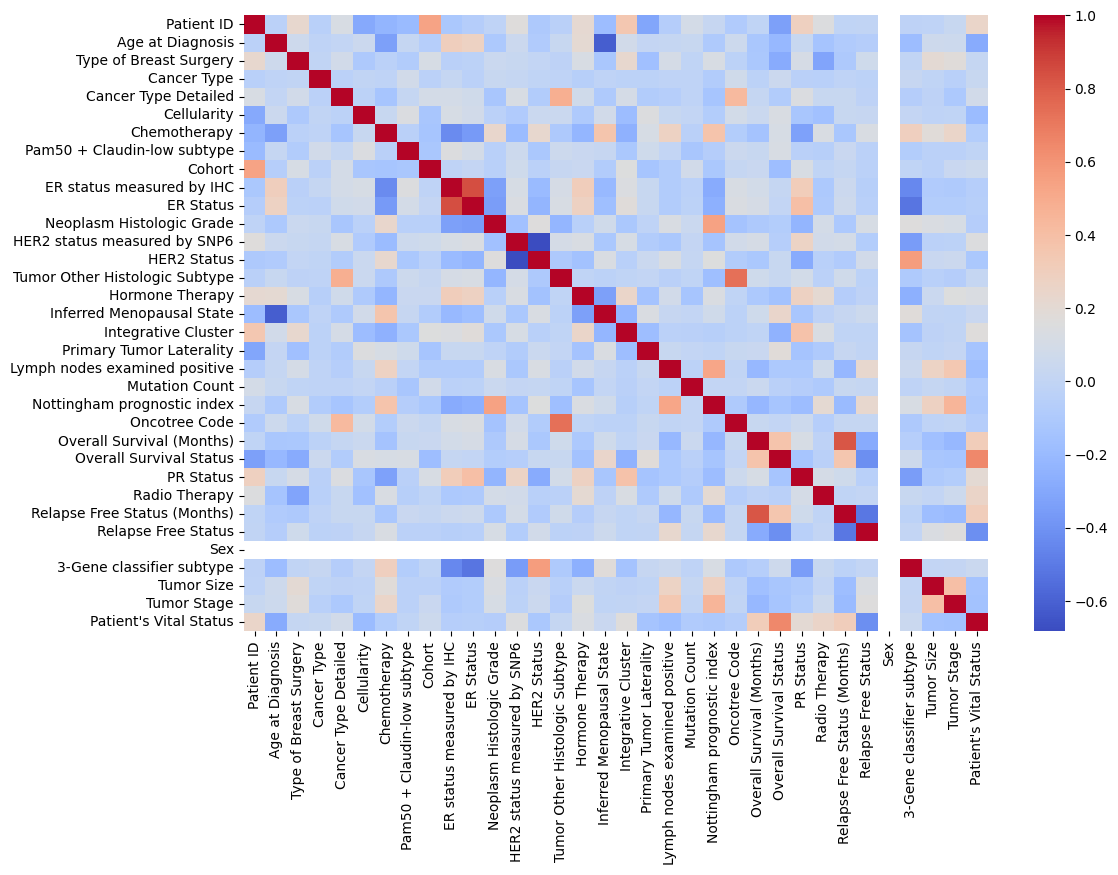

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.show()


**Interpretation:**

“This heatmap shows how different features in the dataset are related to each other.
Red color means the features move together, blue means they move in opposite directions, and light color means there is very little or no relationship.”

“Most of the boxes are light in color, which means most features are not strongly related to each other.
Only a few features show some relationship, especially features related to survival time and survival status.”

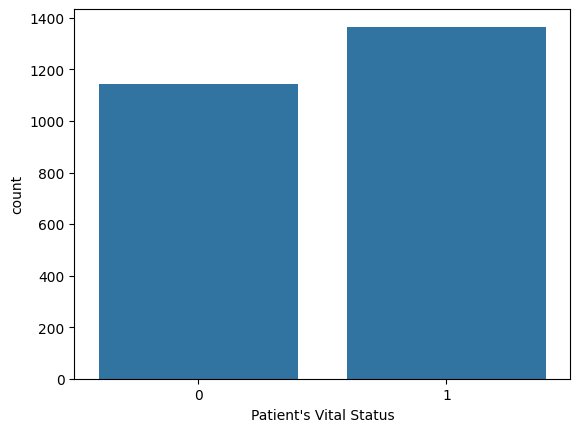

In [ ]:
sns.countplot(x=y)
plt.show()


Interpretation:

“This bar chart compares two categories based on their count.
We can see that the second category has a higher count than the first one.
This means the second group has more observations compared to the first group.

In [ ]:
X = df.drop("Patient's Vital Status", axis=1)
y = df["Patient's Vital Status"]

# step 8: Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# Step 9: Prediction & Evaluation  
The model performance was evaluated using accuracy and classification metrics.

In [ ]:
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression

# Initialize and train the Logistic Regression model
log_model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' solver is often good for smaller datasets and handles L1/L2 penalties
log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, log_pred))
print(classification_report(y_test, log_pred))

Logistic Regression Accuracy: 0.9960159362549801
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       222
           1       1.00      1.00      1.00       280

    accuracy                           1.00       502
   macro avg       1.00      1.00      1.00       502
weighted avg       1.00      1.00      1.00       502



# Step 10 MODEL 2: Random Forest Classifier
Train Random Forest Model
Random Forest was used because it handles complex relationships and feature interactions well.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

# Step 11 Prediction & Evaluation

In [ ]:
rf_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))


Random Forest Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       222
           1       1.00      1.00      1.00       280

    accuracy                           1.00       502
   macro avg       1.00      1.00      1.00       502
weighted avg       1.00      1.00      1.00       502



# STEP 12: Apply Cross-Validation

In [ ]:
from sklearn.model_selection import cross_val_score


In [ ]:
log_cv = cross_val_score(
    log_model, X, y, cv=5, scoring='accuracy'
)

print("Logistic Regression CV Accuracy:", log_cv.mean())


Logistic Regression CV Accuracy: 0.9669211378040732


# Step 13: Random Forest CV
Cross-validation was used to ensure that the model performance is stable and not dependent on a single train-test split.

In [ ]:
rf_cv = cross_val_score(
    rf_model, X, y, cv=5, scoring='accuracy'
)

print("Random Forest CV Accuracy:", rf_cv.mean())


Random Forest CV Accuracy: 0.9078313492536839
